In [1]:
import sys, os, pandas as pd, numpy as np
sys.path.append('src')
from plot_style import set_publication_style
set_publication_style()

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

os.makedirs('results', exist_ok=True)

df = pd.read_csv('data/cleaned_data.csv')
log_cols = [c for c in df.columns if c.endswith('_log')]
X = df[log_cols]
y = df['behavior_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')

In [2]:
results_table = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Random Forest', 'XGBoost'],
    'MAE': [round(mean_absolute_error(y_test, baseline_pred), 2),
            round(mean_absolute_error(y_test, rf_pred), 2),
            round(mean_absolute_error(y_test, xgb_pred), 2)],
    'R2': [round(r2_score(y_test, baseline_pred), 3),
           round(r2_score(y_test, rf_pred), 3),
           round(r2_score(y_test, xgb_pred), 3)],
    'CV_R2_mean_SD': ['-', str(round(cv_scores.mean(),3)) + ' +/- ' + str(round(cv_scores.std(),3)), '-']
})
results_table

,Model,MAE,R2,CV_R2_mean_SD
0,Baseline (mean),6.83,-0.024,-
1,Random Forest,5.82,0.173,0.091 +/- 0.128
2,XGBoost,5.62,0.217,-


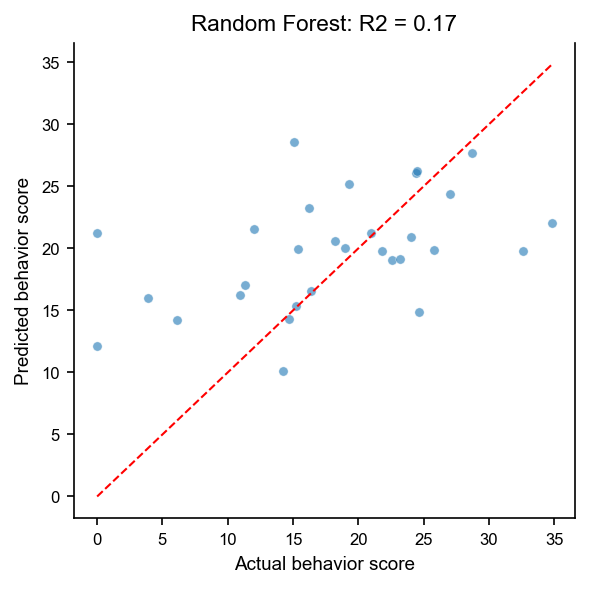

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(y_test, rf_pred, alpha=0.6, s=20, edgecolor='white', linewidth=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
ax.set_xlabel('Actual behavior score')
ax.set_ylabel('Predicted behavior score')
ax.set_title('Random Forest: R2 = ' + str(round(r2_score(y_test, rf_pred), 2)))
plt.tight_layout()
plt.savefig('results/Figure2_predicted_vs_actual.pdf')
plt.savefig('results/Figure2_predicted_vs_actual.png', dpi=300)
plt.show()